In [146]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [1]:
!pip install scikit-learn

In [9]:
import pandas as pd

# Assuming your dataset is already in a DataFrame called 'data'
rice_data = data[data['Substrate'] == 'Rice'].reset_index(drop=True)

# Check how many rows we have for Rice
print("Number of Rice batches:", len(rice_data))
rice_data.head()

Number of Rice batches: 109


,Substrate,Moisture,Temperature,pH,Light_hours,Humidity,Inoculum_density,Strain,Culture_age,Spore_yield
0,Rice,55.831581,28.684680,5.974234,8.347418,72.400374,332042.182683,Strain_A,7.959626,2.745143e+06
1,Rice,50.990578,20.224693,6.947678,1.115888,83.501248,902920.794782,Strain_C,9.485922,1.684061e+06
2,Rice,48.830610,22.686774,5.507410,7.058427,71.742084,808626.584498,Strain_A,7.316744,1.735217e+06
3,Rice,54.019383,22.723073,5.544960,9.659868,75.842228,175648.090961,Strain_C,10.924059,2.094493e+06
4,Rice,41.696754,22.740552,6.954868,0.702611,78.305672,272672.876180,Strain_A,7.691160,1.473335e+06


In [51]:
# Remove the 'Substrate' column
rice_data = rice_data.drop(columns=['Substrate'])

# Verify
print(rice_data.head())

    Moisture  Temperature        pH  Light_hours   Humidity  Inoculum_density  \
0  55.831581    28.684680  5.974234     8.347418  72.400374     332042.182683   
1  50.990578    20.224693  6.947678     1.115888  83.501248     902920.794782   
2  48.830610    22.686774  5.507410     7.058427  71.742084     808626.584498   
3  54.019383    22.723073  5.544960     9.659868  75.842228     175648.090961   
4  41.696754    22.740552  6.954868     0.702611  78.305672     272672.876180   

   Culture_age   Spore_yield  Strain_Strain_B  Strain_Strain_C  
0     7.959626  2.745143e+06                0                0  
1     9.485922  1.684061e+06                0                1  
2     7.316744  1.735217e+06                0                0  
3    10.924059  2.094493e+06                0                1  
4     7.691160  1.473335e+06                0                0  


In [52]:
# Save only Rice data
rice_data.to_csv("metarhizium_rice_data.csv", index=False)

In [53]:
rice_data.head()

,Moisture,Temperature,pH,Light_hours,Humidity,Inoculum_density,Culture_age,Spore_yield,Strain_Strain_B,Strain_Strain_C
0,55.831581,28.684680,5.974234,8.347418,72.400374,332042.182683,7.959626,2.745143e+06,0,0
1,50.990578,20.224693,6.947678,1.115888,83.501248,902920.794782,9.485922,1.684061e+06,0,1
2,48.830610,22.686774,5.507410,7.058427,71.742084,808626.584498,7.316744,1.735217e+06,0,0
3,54.019383,22.723073,5.544960,9.659868,75.842228,175648.090961,10.924059,2.094493e+06,0,1
4,41.696754,22.740552,6.954868,0.702611,78.305672,272672.876180,7.691160,1.473335e+06,0,0


In [54]:
rice_data.shape

(109, 10)

In [55]:
rice_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Moisture,109.0,4.876020e+01,5.494901,4.029089e+01,4.369042e+01,4.883061e+01,5.248476e+01,5.960065e+01
Temperature,109.0,2.529338e+01,3.022207,2.017874e+01,2.268677e+01,2.541901e+01,2.817967e+01,2.997934e+01
pH,109.0,6.284705e+00,0.434115,5.507410e+00,5.943167e+00,6.320046e+00,6.671142e+00,6.995045e+00
Light_hours,109.0,5.690491e+00,3.411879,9.196839e-02,2.726155e+00,5.567177e+00,8.735272e+00,1.174926e+01
Humidity,109.0,7.779223e+01,4.575427,7.000202e+01,7.342353e+01,7.760381e+01,8.216318e+01,8.464021e+01
Inoculum_density,109.0,4.718099e+05,268967.820373,4.083760e+04,2.550842e+05,4.448185e+05,7.041282e+05,9.961961e+05
Culture_age,109.0,1.046277e+01,1.994834,7.056414e+00,8.660011e+00,1.070800e+01,1.233173e+01,1.392829e+01
Spore_yield,109.0,2.446687e+06,539845.448585,1.399762e+06,2.066896e+06,2.403246e+06,2.906372e+06,3.734276e+06
Strain_Strain_B,109.0,3.119266e-01,0.465420,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Strain_Strain_C,109.0,3.577982e-01,0.481566,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


In [56]:
rice_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Moisture          109 non-null    float64
 1   Temperature       109 non-null    float64
 2   pH                109 non-null    float64
 3   Light_hours       109 non-null    float64
 4   Humidity          109 non-null    float64
 5   Inoculum_density  109 non-null    float64
 6   Culture_age       109 non-null    float64
 7   Spore_yield       109 non-null    float64
 8   Strain_Strain_B   109 non-null    int64  
 9   Strain_Strain_C   109 non-null    int64  
dtypes: float64(8), int64(2)
memory usage: 8.6 KB


In [57]:
cat_columns=rice_data.select_dtypes(include=['object']).columns
cat_columns

Index([], dtype='str')

In [58]:
rice_data.head()

,Moisture,Temperature,pH,Light_hours,Humidity,Inoculum_density,Culture_age,Spore_yield,Strain_Strain_B,Strain_Strain_C
0,55.831581,28.684680,5.974234,8.347418,72.400374,332042.182683,7.959626,2.745143e+06,0,0
1,50.990578,20.224693,6.947678,1.115888,83.501248,902920.794782,9.485922,1.684061e+06,0,1
2,48.830610,22.686774,5.507410,7.058427,71.742084,808626.584498,7.316744,1.735217e+06,0,0
3,54.019383,22.723073,5.544960,9.659868,75.842228,175648.090961,10.924059,2.094493e+06,0,1
4,41.696754,22.740552,6.954868,0.702611,78.305672,272672.876180,7.691160,1.473335e+06,0,0


In [61]:
rice_data.head()

,Moisture,Temperature,pH,Light_hours,Humidity,Inoculum_density,Culture_age,Spore_yield,Strain_Strain_B,Strain_Strain_C
0,55.831581,28.684680,5.974234,8.347418,72.400374,332042.182683,7.959626,2.745143e+06,0,0
1,50.990578,20.224693,6.947678,1.115888,83.501248,902920.794782,9.485922,1.684061e+06,0,1
2,48.830610,22.686774,5.507410,7.058427,71.742084,808626.584498,7.316744,1.735217e+06,0,0
3,54.019383,22.723073,5.544960,9.659868,75.842228,175648.090961,10.924059,2.094493e+06,0,1
4,41.696754,22.740552,6.954868,0.702611,78.305672,272672.876180,7.691160,1.473335e+06,0,0


In [62]:
# Select all boolean columns
bool_cols = rice_data.select_dtypes(include='bool').columns

# Convert boolean columns to integers (0/1)
rice_data[bool_cols] = rice_data[bool_cols].astype(int)

In [63]:
rice_data.head()

,Moisture,Temperature,pH,Light_hours,Humidity,Inoculum_density,Culture_age,Spore_yield,Strain_Strain_B,Strain_Strain_C
0,55.831581,28.684680,5.974234,8.347418,72.400374,332042.182683,7.959626,2.745143e+06,0,0
1,50.990578,20.224693,6.947678,1.115888,83.501248,902920.794782,9.485922,1.684061e+06,0,1
2,48.830610,22.686774,5.507410,7.058427,71.742084,808626.584498,7.316744,1.735217e+06,0,0
3,54.019383,22.723073,5.544960,9.659868,75.842228,175648.090961,10.924059,2.094493e+06,0,1
4,41.696754,22.740552,6.954868,0.702611,78.305672,272672.876180,7.691160,1.473335e+06,0,0


In [64]:
corr=rice_data.corr()
corr

,Moisture,Temperature,pH,Light_hours,Humidity,Inoculum_density,Culture_age,Spore_yield,Strain_Strain_B,Strain_Strain_C
Moisture,1.000000,-0.030951,-0.045068,-0.023329,-0.072663,0.247794,-0.029494,0.460098,-0.056256,0.100058
Temperature,-0.030951,1.000000,0.025140,0.367632,0.153872,-0.045644,0.019183,0.555748,0.074143,0.036872
pH,-0.045068,0.025140,1.000000,0.047261,0.050970,-0.072387,0.244799,0.105631,-0.096209,-0.115650
Light_hours,-0.023329,0.367632,0.047261,1.000000,-0.282197,-0.083106,0.050513,0.190998,-0.042313,-0.003226
Humidity,-0.072663,0.153872,0.050970,-0.282197,1.000000,0.047103,0.040466,0.119618,0.163924,-0.047644
Inoculum_density,0.247794,-0.045644,-0.072387,-0.083106,0.047103,1.000000,-0.135821,0.073033,0.076742,-0.090867
Culture_age,-0.029494,0.019183,0.244799,0.050513,0.040466,-0.135821,1.000000,0.513066,0.057947,-0.015602
Spore_yield,0.460098,0.555748,0.105631,0.190998,0.119618,0.073033,0.513066,1.000000,0.391066,-0.278902
Strain_Strain_B,-0.056256,0.074143,-0.096209,-0.042313,0.163924,0.076742,0.057947,0.391066,1.000000,-0.502565
Strain_Strain_C,0.100058,0.036872,-0.115650,-0.003226,-0.047644,-0.090867,-0.015602,-0.278902,-0.502565,1.000000


In [65]:
corr_matrix=rice_data.corr()

In [68]:
# Compute correlation matrix
corr_matrix = rice_data.corr()

# Get correlation of all features with Spore_yield, excluding Spore_yield itself
corr = corr_matrix['Spore_yield'].drop('Spore_yield')

print(corr)

Moisture            0.460098
Temperature         0.555748
pH                  0.105631
Light_hours         0.190998
Humidity            0.119618
Inoculum_density    0.073033
Culture_age         0.513066
Strain_Strain_B     0.391066
Strain_Strain_C    -0.278902
Name: Spore_yield, dtype: float64


In [80]:
sorted_corr=corr.abs().sort_values(ascending=False)
print(corr)

Moisture            0.460098
Temperature         0.555748
pH                  0.105631
Light_hours         0.190998
Humidity            0.119618
Inoculum_density    0.073033
Culture_age         0.513066
Strain_Strain_B     0.391066
Strain_Strain_C    -0.278902
Name: Spore_yield, dtype: float64


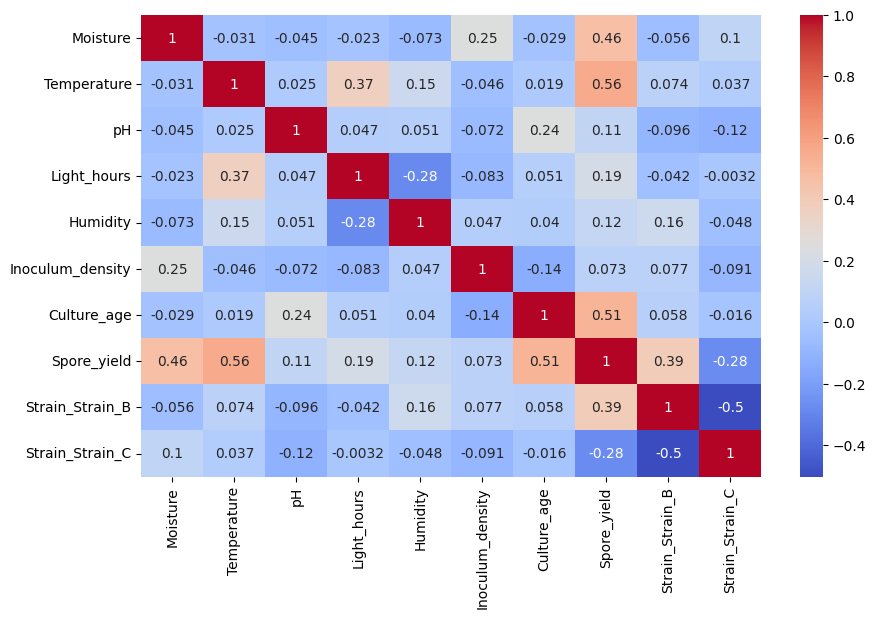

In [76]:
plt.figure(figsize=(10,6))
sns.heatmap(rice_data.corr(),annot=True,cmap='coolwarm')
plt.show()

In [130]:
# Features
X = rice_data.drop(columns=["Spore_yield"])

# Target (log-transform to stabilize large values)
y = np.log10(rice_data["Spore_yield"])

In [120]:
model=LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [121]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [122]:
Scaler = StandardScaler()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [123]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [124]:
#y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 69654.13532993033
MSE: 6984905084.940212
RMSE: 83575.74459698347
R2: 0.978605161681837


In [134]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [139]:
scaler = StandardScaler()
X_train_scaled=Scaler.fit_transform(X_train)
X_test_scaled=Scaler.transform(X_test)

In [140]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [141]:
y_pred_log=model.predict(X_test_scaled)
y_pred_original=10**y_pred_log

In [148]:
print("MAE (log_scale):",mean_absolute_error(y_test,y_pred_log))
print("MSE (log_scale):",mean_squared_error(y_test,y_pred_log))
print("RMSE (log-scale):", np.sqrt(mean_squared_error(y_test, y_pred_log)))
print("R2 (log_scale):",r2_score(y_test,y_pred_log))

MAE (log_scale): 0.054890265684652384
MSE (log_scale): 0.00397022555439841
RMSE (log-scale): 0.06300972587147487
R2 (log_scale): 0.6365521050195467


## On average, predicted spore yield is within ±15% of the true value.

# LinearRegression

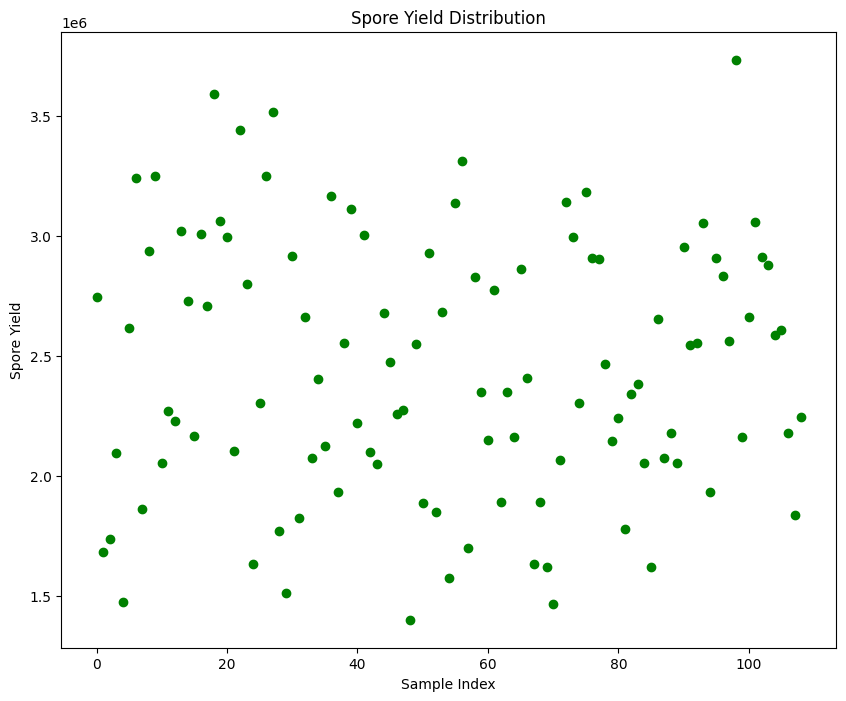

In [153]:
plt.figure(figsize=(10,8))
plt.scatter(range(len(rice_data)), rice_data['Spore_yield'], color='green')
plt.xlabel('Sample Index')
plt.ylabel('Spore Yield')
plt.title('Spore Yield Distribution')
plt.show()

Feature importances (descending):
Temperature         0.376668
Culture_age         0.277897
Moisture            0.183511
Strain_Strain_B     0.031252
Strain_Strain_C     0.030800
pH                  0.029432
Humidity            0.024519
Inoculum_density    0.024040
Light_hours         0.021881
dtype: float64

Correlation with Spore_yield:
Spore_yield         1.000000
Temperature         0.555748
Culture_age         0.513066
Moisture            0.460098
Strain_Strain_B     0.391066
Light_hours         0.190998
Humidity            0.119618
pH                  0.105631
Inoculum_density    0.073033
Strain_Strain_C    -0.278902
Name: Spore_yield, dtype: float64


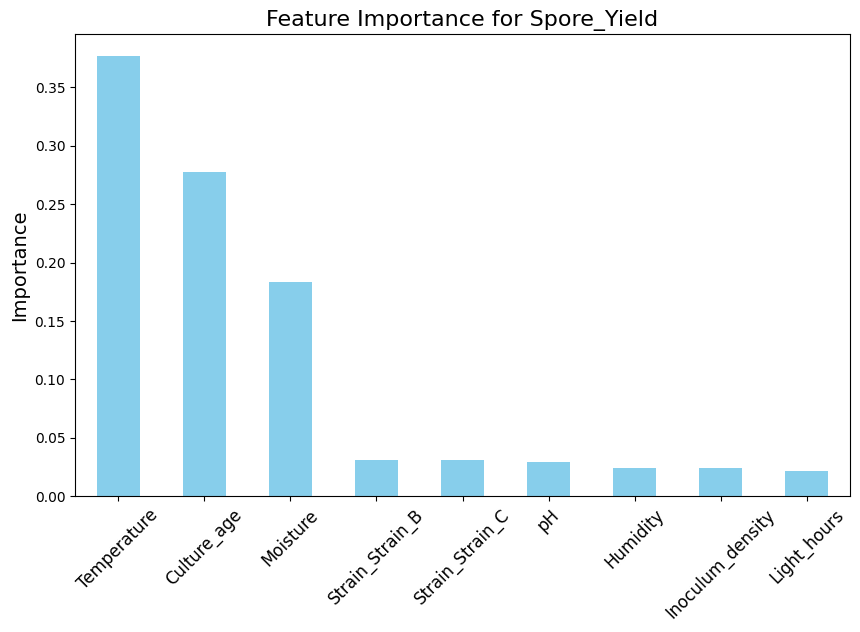

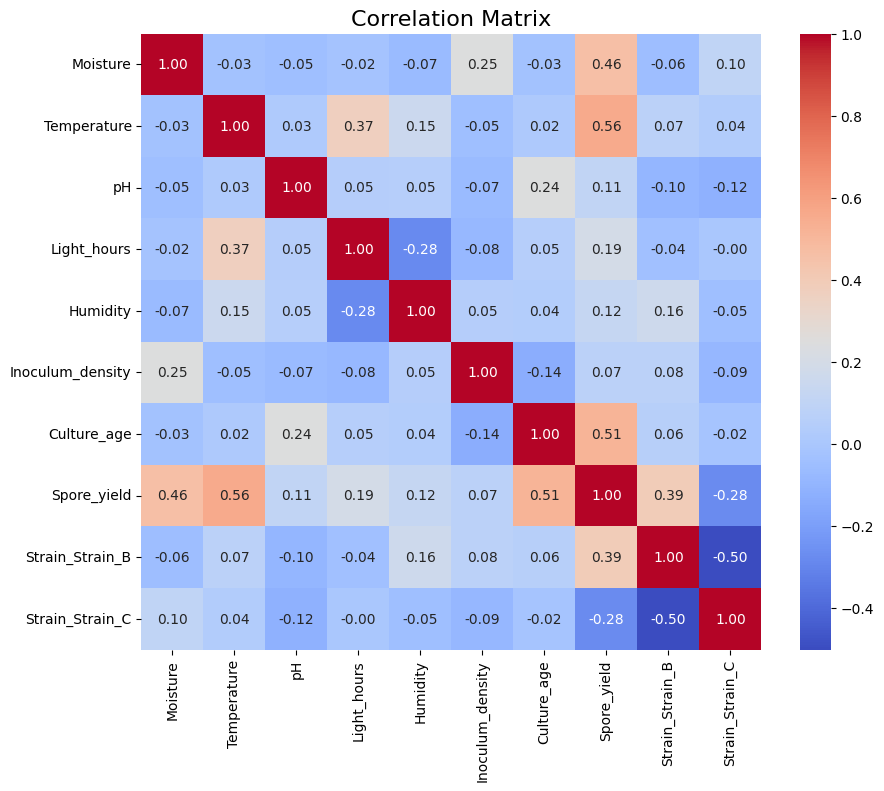

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# --- Data preparation ---
X = rice_data.drop(columns=['Spore_yield'])
y = np.log10(rice_data['Spore_yield'])  # log-transform for stability

# Optional: scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Random Forest for feature importance ---
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_scaled, y)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print("Feature importances (descending):")
print(importances)

# --- Correlation with target ---
correlations = rice_data.corr()['Spore_yield'].sort_values(ascending=False)
print("\nCorrelation with Spore_yield:")
print(correlations)

# --- Plot feature importance ---
plt.figure(figsize=(10,6))
importances.plot(kind='bar', color='skyblue')
plt.title('Feature Importance for Spore_Yield', fontsize=16)
plt.ylabel('Importance', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.show()

# --- Optional: Heatmap of correlations ---
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(rice_data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features and target
X = rice_data.drop(columns=['Spore_yield'])
y = np.log10(rice_data['Spore_yield'])  # log-transform

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Calculate residuals
residuals = y_test - y_pred

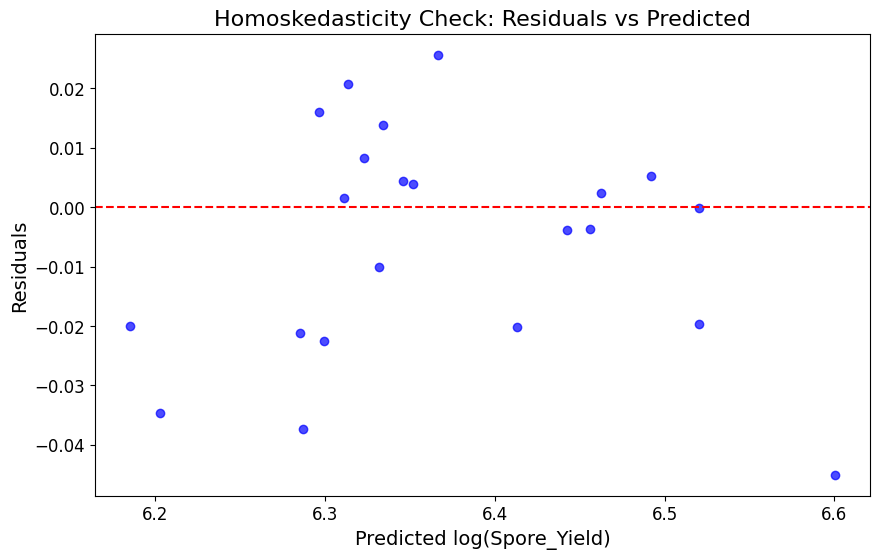

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, color='blue', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted log(Spore_Yield)", fontsize=14)
plt.ylabel("Residuals", fontsize=14)
plt.title("Homoskedasticity Check: Residuals vs Predicted", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()